In [ ]:
import numpy as np

#  a: Centering the Data 

# dataset
x = np.array([2.5, 0.5, 2.2, 1.9, 3.1, 2.3, 2.0, 1.0, 1.5, 1.1])
y = np.array([2.4, 0.7, 2.9, 2.2, 3.0, 2.7, 1.6, 1.1, 1.6, 0.9])

# Combininh into a single matrix (10 rows, 2 columns)
X = np.column_stack((x, y))

# Getting the means of the columns
mean_vals = np.mean(X, axis=0)
print(f"Means (x, y): {mean_vals}\n")

# Centering the data by subtracting the means
# X_mu matrix
X_mu = X - mean_vals

print("Centered Data Matrix (X_mu):")
print(X_mu)
print("-" * 30)

#  b: Calculate the Covariance Matrix

# Using the formula: C = (1 / (n-1)) * (X_mu^T * X_mu)
n = X_mu.shape[0] 

# X_mu.T is the transpose. 
# The '@' symbol does the matrix multiplication in numpy.
C = (1 / (n - 1)) * (X_mu.T @ X_mu)

print("Covariance Matrix (C):")
print(C)



# Using numpy's linear algebra solver to find the eigenpairs
eigenvalues, eigenvectors = np.linalg.eig(C)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors (each column is a vector):")
print(eigenvectors)

Means (x, y): [1.81 1.91]

Centered Data Matrix (X_mu):
[[ 0.69  0.49]
 [-1.31 -1.21]
 [ 0.39  0.99]
 [ 0.09  0.29]
 [ 1.29  1.09]
 [ 0.49  0.79]
 [ 0.19 -0.31]
 [-0.81 -0.81]
 [-0.31 -0.31]
 [-0.71 -1.01]]
------------------------------
Covariance Matrix (C):
[[0.61655556 0.61544444]
 [0.61544444 0.71655556]]
Eigenvalues:
[0.0490834  1.28402771]

Eigenvectors (each COLUMN is a vector):
[[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]


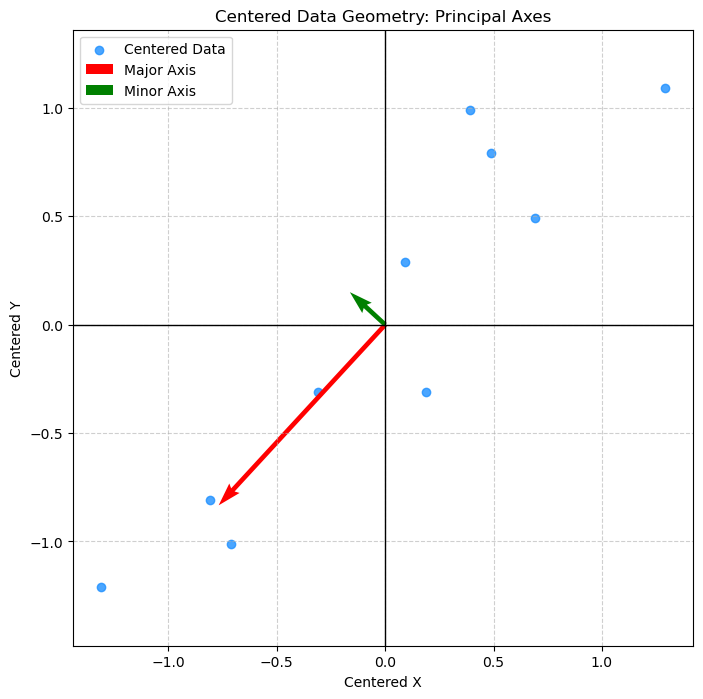

In [ ]:
import matplotlib.pyplot as plt

# Create a square figure so the axes aren't distorted
plt.figure(figsize=(8, 8))

# 1. Scatter plot of the centered data (extracting x and y columns from X_mu)
plt.scatter(X_mu[:, 0], X_mu[:, 1], color='dodgerblue', alpha=0.8, label='Centered Data')

# 2. Extract and scale the eigenvectors
# Output index 1 is our major axis, index 0 is our minor axis
origin = [0, 0]

# Major Axis (Largest eigenvalue)
major_val = eigenvalues[1]
major_vec = eigenvectors[:, 1]
scaled_major = major_vec * np.sqrt(major_val)

# Minor Axis (Smallest eigenvalue)
minor_val = eigenvalues[0]
minor_vec = eigenvectors[:, 0]
scaled_minor = minor_vec * np.sqrt(minor_val)

# plotting the arrows using plt.quiver
plt.quiver(*origin, scaled_major[0], scaled_major[1], color='red', scale=1, scale_units='xy', angles='xy', label=f'Major Axis')
plt.quiver(*origin, scaled_minor[0], scaled_minor[1], color='green', scale=1, scale_units='xy', angles='xy', label=f'Minor Axis')

# Formatting the plot to make it look clean
plt.axhline(0, color='black', linewidth=1) # x-axis
plt.axvline(0, color='black', linewidth=1) # y-axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal') # Ensures the 90-degree angle looks 90 degrees
plt.title('Centered Data Geometry: Principal Axes')
plt.xlabel('Centered X')
plt.ylabel('Centered Y')
plt.legend()
plt.show()

In [ ]:
# 2a: Compute SVD of the centered data matrix
U, sigma, Vt = np.linalg.svd(X_mu, full_matrices=False)

print("Singular values (sigma):", sigma)
print("\nRight singular vectors (rows of Vt, the columns of V):")
print(Vt.T)  # Each COLUMN of V is a right singular vector
print("\nFor comparison, our eigenvectors from Problem 1:")
print(eigenvectors)

Singular values (sigma): [3.3994484  0.66464321]

Right singular vectors (rows of Vt, the columns of V):
[[-0.6778734   0.73517866]
 [-0.73517866 -0.6778734 ]]

For comparison, our eigenvectors from Problem 1:
[[-0.73517866 -0.6778734 ]
 [ 0.6778734  -0.73517866]]


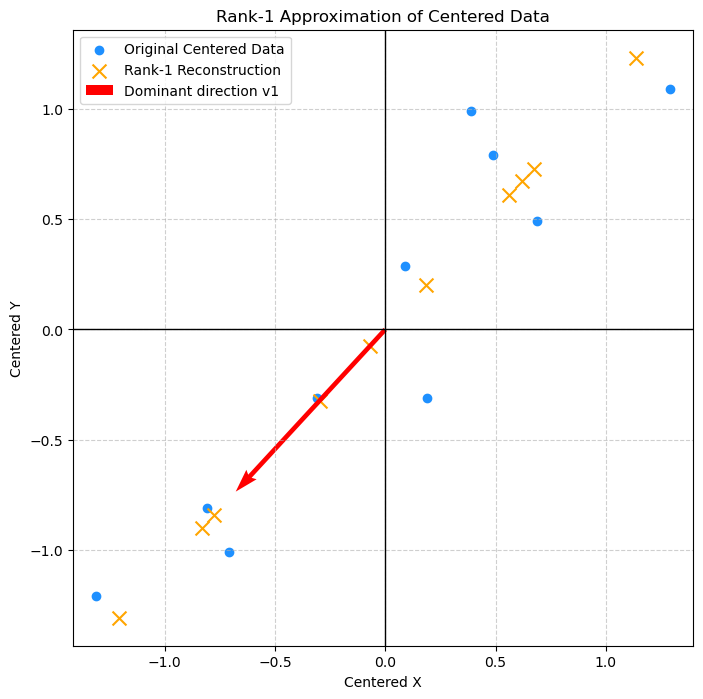

In [ ]:
# 2b: Rank-1 approximation X1 = sigma1 * u1 * v1^T
u1 = U[:, 0].reshape(-1, 1)   # first left singular vector (column)
v1 = Vt[0, :].reshape(1, -1)  # first right singular vector (row)
X1 = sigma[0] * (u1 @ v1)     # rank-1 reconstruction

plt.figure(figsize=(8, 8))
plt.scatter(X_mu[:, 0], X_mu[:, 1], color='dodgerblue', label='Original Centered Data')
plt.scatter(X1[:, 0], X1[:, 1], color='orange', marker='x', s=100, label='Rank-1 Reconstruction')

# Drawing the dominant direction v1
origin = [0, 0]
plt.quiver(*origin, Vt[0,0], Vt[0,1], color='red', scale=1, scale_units='xy', angles='xy', label='Dominant direction v1')

plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal')
plt.title('Rank-1 Approximation of Centered Data')
plt.xlabel('Centered X')
plt.ylabel('Centered Y')
plt.legend()
plt.show()

In [ ]:
# 2c: Square the singular values
sigma1_sq = sigma[0]**2
sigma2_sq = sigma[1]**2
total = sigma1_sq + sigma2_sq

print(f"sigma1^2 = {sigma1_sq:.4f}")
print(f"sigma2^2 = {sigma2_sq:.4f}")
print(f"Fraction captured by sigma1: {sigma1_sq / total:.4f}")

sigma1^2 = 11.5562
sigma2^2 = 0.4418
Fraction captured by sigma1: 0.9632
